# 02 - Environment Harmonization

**Runs locally** (no Spark needed — uses cached CSV from NB01)

Classifies Pseudomonas genomes into ecological categories from free-text isolation sources.
Then aggregates to species-level lifestyle assignments.

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data') if os.path.basename(os.getcwd()) == 'notebooks' else 'data'
FIG_DIR = os.path.join(os.path.dirname(os.getcwd()), 'figures') if os.path.basename(os.getcwd()) == 'notebooks' else 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

isolation_df = pd.read_csv(os.path.join(DATA_DIR, 'isolation_sources.csv'))
species_df = pd.read_csv(os.path.join(DATA_DIR, 'pseudomonas_species.csv'))
print(f'Loaded {len(isolation_df):,} genomes, {len(species_df)} species')

Loaded 12,732 genomes, 433 species


## 1. Keyword-Based Environment Classification

Classify isolation sources into broad ecological categories using keyword matching.
Priority order matters — a genome matching multiple categories takes the first match.

In [2]:
# Combine isolation source fields into a single text field for matching
isolation_df['source_text'] = (
    isolation_df['ncbi_env_isolation_source'].fillna('') + ' | ' +
    isolation_df['gtdb_isolation_source'].fillna('') + ' | ' +
    isolation_df['host'].fillna('') + ' | ' +
    isolation_df['env_broad_scale'].fillna('') + ' | ' +
    isolation_df['env_local_scale'].fillna('') + ' | ' +
    isolation_df['env_medium'].fillna('')
).str.lower()

# Define classification rules (order = priority)
ENVIRONMENT_RULES = [
    ('clinical', r'sputum|blood|urine|wound|lung|hospital|cystic fibrosis|cf patient|'
                 r'respiratory|bronchoalveolar|trachea|icu|burn|abscess|catheter|'
                 r'clinical|bacteremia|infection|biopsy|cornea|\beye\b|'
                 r'intra-abdominal|urinary tract'),
    ('human_other', r'\bhuman\b|homo sapiens|feces|stool|gut|nasal|skin|oral|saliva'),
    ('animal', r'\bfish\b|chicken|poultry|bovine|cattle|pig|porcine|horse|equine|'
              r'insect|larvae|shrimp|\bmeat\b|animal'),
    ('plant_surface', r'\bleaf\b|phyllosphere|plant|flower|fruit|seed|stem|root surface|'
                      r'tomato|tobacco|bean|cherry|olive|kiwi|mushroom|canker'),
    ('rhizosphere', r'rhizosphere|rhizoplane|root\b|endophyte|nodule'),
    ('soil', r'\bsoil\b|agricultural soil|bulk soil|forest soil|grassland|compost|sediment'),
    ('freshwater', r'\briver\b|\blake\b|\bstream\b|freshwater|groundwater|spring|well water|'
                   r'drinking water|tap water|wastewater|activated sludge'),
    ('marine', r'\bsea\b|\bocean\b|marine|seawater|coral|coastal|estuar'),
    ('food_dairy', r'\bmilk\b|dairy|cheese|yogurt|raw milk|pasteurized|food|raw chicken'),
    ('industrial', r'oil|petroleum|hydrocarbon|contaminated|bioreactor|bioremediation|'
                   r'space station|cleanroom|spacecraft'),
]

def classify_environment(text):
    if pd.isna(text) or text.strip() == '| | | | |':
        return 'unknown'
    for category, pattern in ENVIRONMENT_RULES:
        if re.search(pattern, text):
            return category
    # Check for common "missing" values
    if re.search(r'missing|not collected|not available|unknown|n/a', text):
        return 'unknown'
    return 'other'

isolation_df['environment'] = isolation_df['source_text'].apply(classify_environment)

print('Genome-level environment classification:')
env_counts = isolation_df['environment'].value_counts()
for env, count in env_counts.items():
    pct = count / len(isolation_df) * 100
    print(f'  {env:20s}: {count:6,} ({pct:.1f}%)')

Genome-level environment classification:
  clinical            :  4,197 (33.0%)
  other               :  3,711 (29.1%)
  human_other         :  1,659 (13.0%)
  unknown             :    850 (6.7%)
  freshwater          :    566 (4.4%)
  soil                :    551 (4.3%)
  plant_surface       :    503 (4.0%)
  rhizosphere         :    275 (2.2%)
  food_dairy          :    141 (1.1%)
  animal              :    136 (1.1%)
  industrial          :     80 (0.6%)
  marine              :     63 (0.5%)


In [3]:
# Group into lifestyle categories
LIFESTYLE_MAP = {
    'clinical': 'host_associated',
    'human_other': 'host_associated',
    'animal': 'host_associated',
    'plant_surface': 'plant_associated',
    'rhizosphere': 'free_living',
    'soil': 'free_living',
    'freshwater': 'free_living',
    'marine': 'free_living',
    'food_dairy': 'food_associated',
    'industrial': 'free_living',
    'other': 'unknown',
    'unknown': 'unknown',
}

isolation_df['lifestyle'] = isolation_df['environment'].map(LIFESTYLE_MAP)

print('Lifestyle distribution:')
print(isolation_df['lifestyle'].value_counts().to_string())

Lifestyle distribution:
lifestyle
host_associated     5992
unknown             4561
free_living         1535
plant_associated     503
food_associated      141


## 2. Species-Level Aggregation

For each species, determine the majority environment and lifestyle based on its genomes.

In [4]:
# Compute species-level environment profile
known_only = isolation_df[isolation_df['lifestyle'] != 'unknown'].copy()

species_env = known_only.groupby('gtdb_species_clade_id').agg(
    n_genomes_classified=('genome_id', 'count'),
    n_environments=('environment', 'nunique'),
    majority_environment=('environment', lambda x: x.value_counts().index[0]),
    majority_lifestyle=('lifestyle', lambda x: x.value_counts().index[0]),
    pct_majority=('environment', lambda x: x.value_counts().iloc[0] / len(x) * 100),
    n_host_associated=('lifestyle', lambda x: (x == 'host_associated').sum()),
    n_free_living=('lifestyle', lambda x: (x == 'free_living').sum()),
    n_plant_associated=('lifestyle', lambda x: (x == 'plant_associated').sum()),
).reset_index()

# Merge with species info
species_env = species_env.merge(species_df[['gtdb_species_clade_id', 'GTDB_species',
                                             'no_genomes', 'gtdb_subgenus', 'core_fraction']],
                                on='gtdb_species_clade_id', how='left')

print(f'Species with classified genomes: {len(species_env)}')
print(f'\nSpecies majority lifestyle:')
print(species_env['majority_lifestyle'].value_counts().to_string())
print(f'\nSpecies majority environment:')
print(species_env['majority_environment'].value_counts().to_string())

Species with classified genomes: 387

Species majority lifestyle:
majority_lifestyle
free_living         204
host_associated     109
plant_associated     59
food_associated      15

Species majority environment:
majority_environment
soil             97
clinical         70
plant_surface    63
freshwater       52
rhizosphere      48
human_other      21
food_dairy       17
animal           14
marine            3
industrial        2


In [5]:
# Cross-tabulate subgenus vs lifestyle
ct = pd.crosstab(species_env['gtdb_subgenus'], species_env['majority_lifestyle'],
                 margins=True)
print('Subgenus vs Lifestyle (species count):')
print(ct.to_string())

Subgenus vs Lifestyle (species count):
majority_lifestyle  food_associated  free_living  host_associated  plant_associated  All
gtdb_subgenus                                                                           
Pseudomonas                       0           10                6                 0   16
Pseudomonas_B                     0            0                2                 2    4
Pseudomonas_E                    15          188               98                57  358
Pseudomonas_F                     0            6                1                 0    7
Pseudomonas_H                     0            0                2                 0    2
All                              15          204              109                59  387


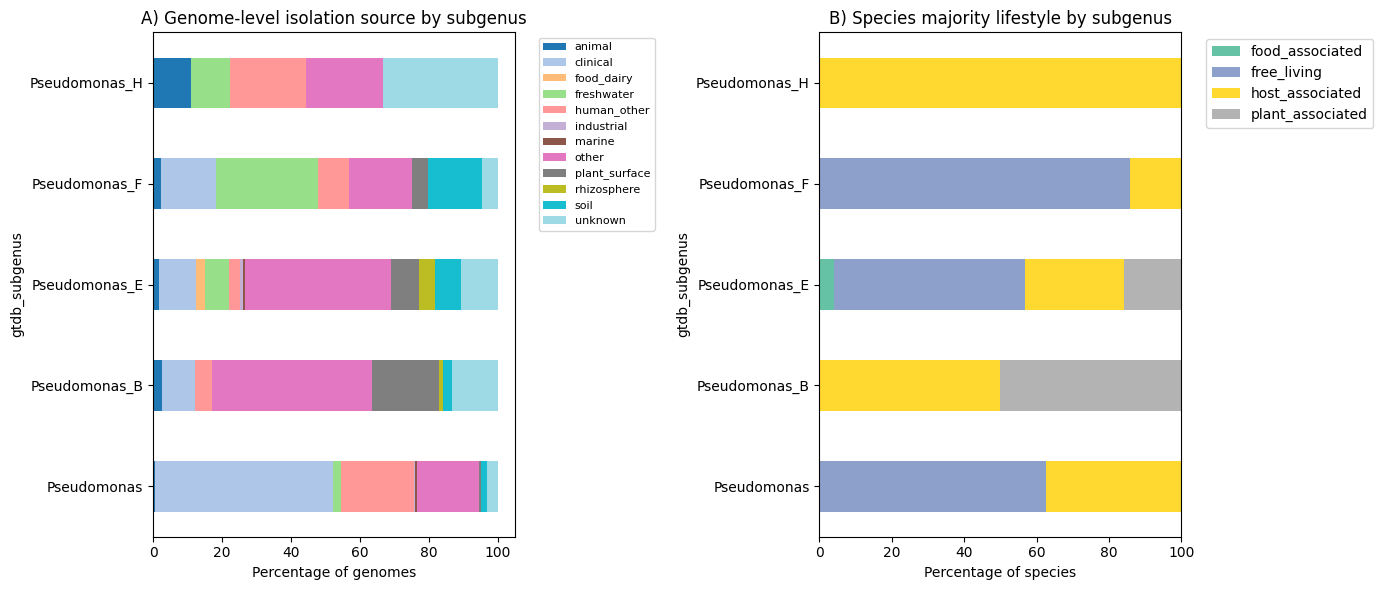

Saved to /home/mamillerpa/BERIL-research-observatory/projects/pseudomonas_carbon_ecology/figures/environment_by_subgenus.png


In [6]:
# Save
isolation_df.to_csv(os.path.join(DATA_DIR, 'genome_environment.csv'), index=False)
species_env.to_csv(os.path.join(DATA_DIR, 'species_lifestyle.csv'), index=False)

# Visualization: environment distribution by subgenus
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Genome-level
genome_ct = pd.crosstab(isolation_df.merge(
    species_df[['gtdb_species_clade_id', 'gtdb_subgenus']],
    on='gtdb_species_clade_id')['gtdb_subgenus'],
    isolation_df['environment'])
genome_ct_pct = genome_ct.div(genome_ct.sum(axis=1), axis=0) * 100
genome_ct_pct.plot(kind='barh', stacked=True, ax=axes[0], colormap='tab20')
axes[0].set_xlabel('Percentage of genomes')
axes[0].set_title('A) Genome-level isolation source by subgenus')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Panel B: Species-level
sp_ct = pd.crosstab(species_env['gtdb_subgenus'], species_env['majority_lifestyle'])
sp_ct_pct = sp_ct.div(sp_ct.sum(axis=1), axis=0) * 100
sp_ct_pct.plot(kind='barh', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_xlabel('Percentage of species')
axes[1].set_title('B) Species majority lifestyle by subgenus')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'environment_by_subgenus.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIG_DIR}/environment_by_subgenus.png')

## Summary

- `genome_environment.csv` — per-genome environment and lifestyle classification
- `species_lifestyle.csv` — per-species majority environment, lifestyle, and diversity